# 01 — Lectura y análisis exploratorio

**TP3 — Análisis de sentimiento en tweets (Sentiment140)**

Carga de los datos y EDA. El objetivo es entender qué señal hay **antes** de modelar.

In [1]:
import html
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (9, 5)

RAW = "../data/raw"
COLUMNS = ["polarity", "id", "date", "query", "user", "text"]

## 1. Carga de datos

In [2]:
COLUMNS = ["polarity", "id", "date", "query", "user", "text"]

df = pd.read_csv(
    "../data/raw/training.1600000.processed.noemoticon.csv",
    encoding="latin-1", header=None, names=COLUMNS,
)
df_test = pd.read_csv(
    "../data/raw/testdata.manual.2009.06.14.csv",
    encoding="latin-1", header=None, names=COLUMNS,
)

print(f"Train: {df.shape}")
print(f"Test (manual):  {df_test.shape}")
df.head(3)


Train: (1600000, 6)
Test (manual):  (498, 6)


,polarity,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...


In [3]:
print("Distribución de clases en TRAIN:")
print(df["polarity"].value_counts())
print()
print("Distribución de clases en TEST manual (incluye neutral=2):")
print(df_test["polarity"].value_counts())


Distribución de clases en TRAIN:
polarity
0    800000
4    800000
Name: count, dtype: int64

Distribución de clases en TEST manual (incluye neutral=2):
polarity
4    182
0    177
2    139
Name: count, dtype: int64


**⚠️ Nota clave del dataset:** el train se etiquetó **automáticamente por emoticón** → solo tiene positivo/negativo, **no hay neutral** (un tweet neutral no lleva emoticón).

El test se etiquetó **a mano** → sí tiene neutral.

→ Ningún modelo entrenado acá va a poder predecir "neutral". Por eso evaluamos contra la **porción binaria** (359 tweets), y al final mostramos el costo de esa limitación.

## 2. Distribución de clases

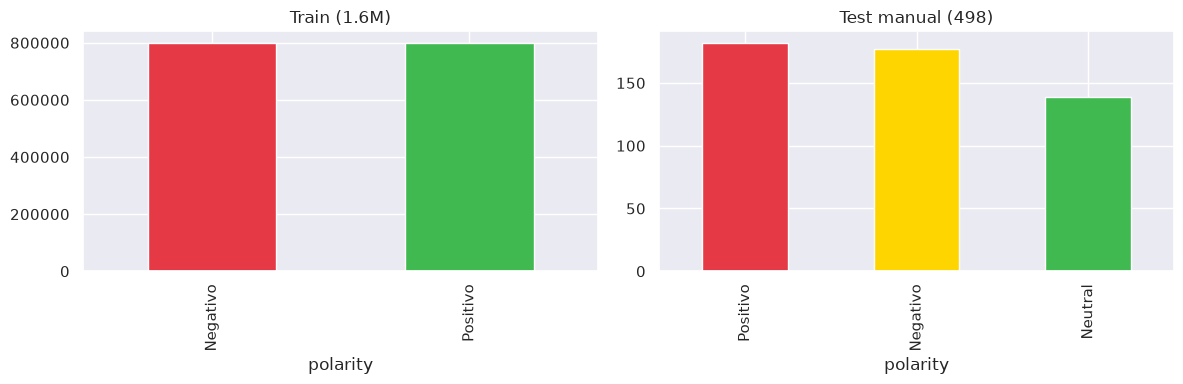

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["polarity"].map({0: "Negativo", 4: "Positivo"}).value_counts().plot(
    kind="bar", ax=ax[0], color=["#e63946", "#3fb950"], title="Train (1.6M)"
)
df_test["polarity"].map({0: "Negativo", 2: "Neutral", 4: "Positivo"}).value_counts().plot(
    kind="bar", ax=ax[1], color=["#e63946", "#ffd500", "#3fb950"], title="Test manual (498)"
)
plt.tight_layout()
plt.show()


**Conclusión**

- Train: **800.000 / 800.000** — balanceado exacto (por diseño del dataset).
- → **No hace falta balancear** nada.
- → **El benchmark del azar es 50%**: contra eso hay que leer todo lo demás.
- Test: 182 pos / 177 neg / **139 neutrales**.
- ⚠️ **La clase neutral no existe en el train** (un tweet neutral no lleva emoticón) → ningún modelo va a poder predecirla.

## 3. ¿El largo del tweet dice algo?

/tmp/ipykernel_2497641/3565089872.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels(["Negativo", "Positivo"])
/tmp/ipykernel_2497641/3565089872.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[1].set_xticklabels(["Negativo", "Positivo"])


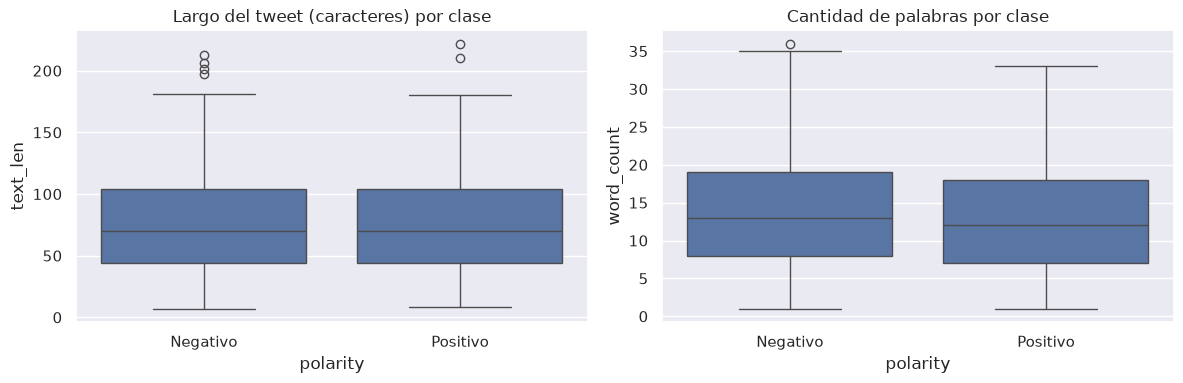

In [5]:
df["text_len"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df.sample(50000, random_state=42), x="polarity", y="text_len", ax=ax[0])
ax[0].set_title("Largo del tweet (caracteres) por clase")
ax[0].set_xticklabels(["Negativo", "Positivo"])
sns.boxplot(data=df.sample(50000, random_state=42), x="polarity", y="word_count", ax=ax[1])
ax[1].set_title("Cantidad de palabras por clase")
ax[1].set_xticklabels(["Negativo", "Positivo"])
plt.tight_layout()
plt.show()


**Conclusión**

| clase | largo | palabras |
|---|---|---|
| Negativo | 70 car. | 13 |
| Positivo | 69 car. | 12 |

- **1 carácter de diferencia: el largo no discrimina nada.**
- → Descarta `text_len` y `word_count` como features.
- → La señal está en **qué** palabras, no en cuántas. Eso justifica bag-of-words.

## 4. ¿Qué palabras usa cada clase?

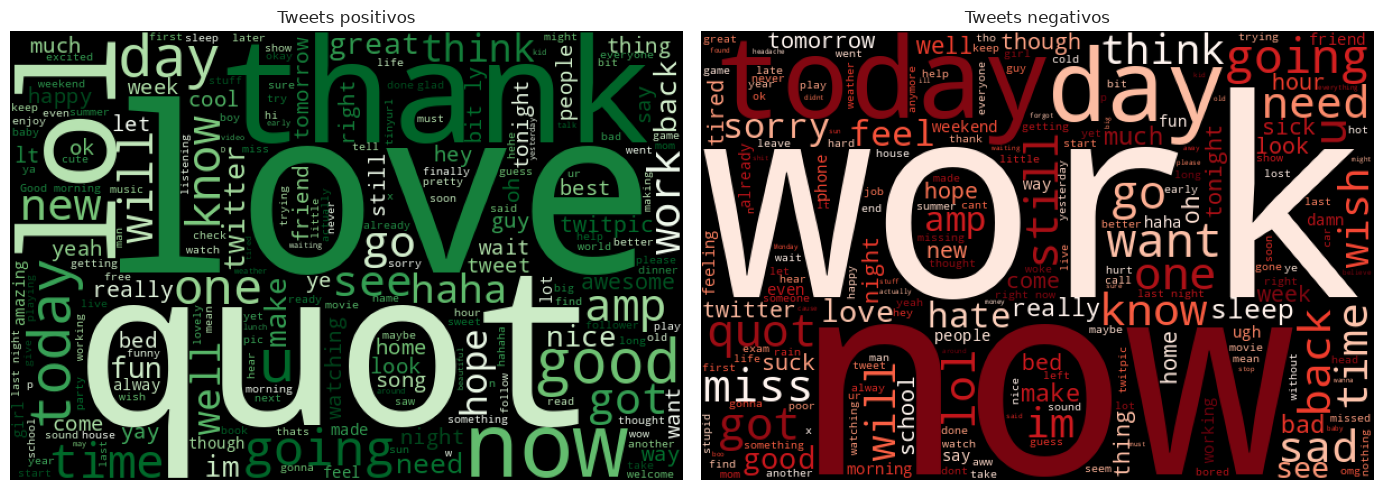

In [6]:
# Wordclouds (sobre una muestra, por velocidad) -- se ven las palabras mas frecuentes
# despues de sacar stopwords basicas de ingles
STOP_WC = set(WordCloud().stopwords)

sample_wc = df.sample(80000, random_state=42)
text_pos = " ".join(sample_wc.loc[sample_wc["polarity"] == 4, "text"])
text_neg = " ".join(sample_wc.loc[sample_wc["polarity"] == 0, "text"])

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
WordCloud(width=600, height=400, background_color="black", colormap="Greens",
          stopwords=STOP_WC).generate(text_pos).to_array()
ax[0].imshow(WordCloud(width=600, height=400, background_color="black", colormap="Greens",
             stopwords=STOP_WC).generate(text_pos))
ax[0].set_title("Tweets positivos")
ax[0].axis("off")
ax[1].imshow(WordCloud(width=600, height=400, background_color="black", colormap="Reds",
             stopwords=STOP_WC).generate(text_neg))
ax[1].set_title("Tweets negativos")
ax[1].axis("off")
plt.tight_layout()
plt.show()


**Conclusión**

- **Vocabulario discriminante:** positivos → `good`, `love`, `thanks`, `lol` | negativos → `work`, `miss`, `want`.
- **Pero mucho se comparte:** `day`, `now`, `today`, `got` están arriba en las dos → anticipa el techo del ~82%.
- → Justifica **TF-IDF**: penaliza las palabras que están en todos lados.

**🔍 Hallazgo de calidad de datos:** aparece `quot` entre las más frecuentes. No es una palabra — es el resto de `&quot;` sin decodificar.

→ **Se corrige en la notebook 02** (decodificar HTML *antes* de limpiar).

## 5. ¿Las marcas de Twitter aportan señal?

### ¿Las marcas de Twitter aportan señal?

Un tweet trae **URLs, @menciones, #hashtags, `!`**. La limpieza los borra asumiendo que son ruido.

**Antes de asumirlo, lo medimos.**

,% tweets que la tienen,Con la marca,Sin la marca,brecha
marca,,,,
Tiene signo ?,10.5,51.5,49.8,1.6
Tiene hashtag (#),2.2,57.6,49.8,7.7
Tiene signo !,30.1,58.8,46.2,12.6
Menciona a alguien (@),46.2,59.3,42.1,17.2
Tiene URL,4.8,66.7,49.2,17.6


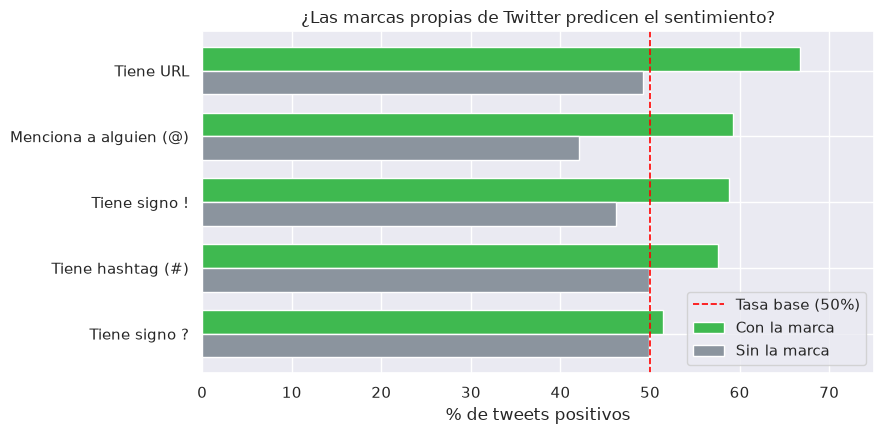

In [7]:
# Se mide sobre el texto CRUDO, antes de limpiar (la limpieza justamente borra estas marcas).
df["pos"] = (df["polarity"] == 4).astype(int)

marcas = {
    "Tiene URL":              df["text"].str.contains(r"https?://|www\.", case=False, regex=True),
    "Menciona a alguien (@)": df["text"].str.contains(r"@\w+", regex=True),
    "Tiene signo !":          df["text"].str.contains("!", regex=False),
    "Tiene hashtag (#)":      df["text"].str.contains(r"#\w+", regex=True),
    "Tiene signo ?":          df["text"].str.contains(r"\?", regex=True),
}

filas = []
for nombre, mask in marcas.items():
    con, sin = df["pos"][mask].mean() * 100, df["pos"][~mask].mean() * 100
    filas.append({"marca": nombre, "% tweets que la tienen": mask.mean() * 100,
                  "Con la marca": con, "Sin la marca": sin, "brecha": abs(con - sin)})
tabla_marcas = pd.DataFrame(filas).sort_values("brecha")
display(tabla_marcas.set_index("marca").round(1))

fig, ax = plt.subplots(figsize=(9, 4.5))
y, h = np.arange(len(tabla_marcas)), 0.36
ax.barh(y + h/2, tabla_marcas["Con la marca"], h, label="Con la marca", color="#3FB950")
ax.barh(y - h/2, tabla_marcas["Sin la marca"], h, label="Sin la marca", color="#8B949E")
ax.axvline(50, ls="--", color="red", lw=1.2, label="Tasa base (50%)")
ax.set_yticks(y); ax.set_yticklabels(tabla_marcas["marca"])
ax.set_xlabel("% de tweets positivos"); ax.set_xlim(0, 75)
ax.set_title("¿Las marcas propias de Twitter predicen el sentimiento?")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Conclusión**

| marca | con | sin | brecha |
|---|---|---|---|
| URL | 66.7% | 49.2% | **+17.6** |
| @mención | 59.3% | 42.1% | **+17.2** |
| `!` | 58.8% | 46.2% | **+12.6** |
| #hashtag | 57.6% | 49.8% | +7.7 |
| `?` | 51.5% | 49.8% | +1.6 (nada) |

- **Tres de cuatro tienen señal fuerte.** Se linkea lo que gusta; se saluda a la gente; `!` = entusiasmo.
- El `?` es el **control negativo**: si todas dieran señal, sospecharíamos del método.
- ⚠️ **La limpieza (notebook 02) las borra a todas** → se descartan porque el TP compara *vectorizaciones*, no maximiza métrica. Queda como vía de mejora.

## 6. Temporalidad

### Temporalidad: ¿a qué hora se tuitea más positivo?

El dataset trae una columna `date` que venimos ignorando.

**Pregunta:** *¿a la madrugada se tuitea más positivo o más negativo?*

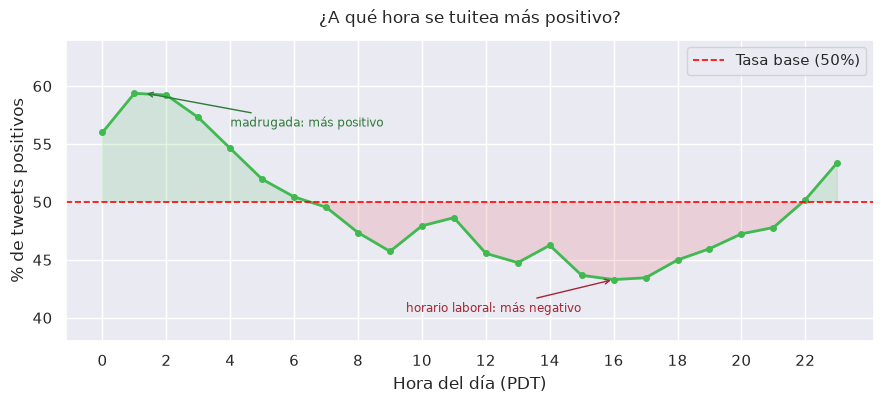

Pico : 59.4% de positivos a las 1h
Piso : 43.3% de positivos a las 16h
Rango: 16.1 puntos entre la mejor y la peor hora


In [8]:
# La fecha viene como "Mon Apr 06 22:19:45 PDT 2009": se saca el "PDT" para poder parsearla.
hora = pd.to_datetime(df["date"].str.replace(" PDT ", " ", regex=False),
                      format="%a %b %d %H:%M:%S %Y", errors="coerce").dt.hour
por_hora = df.assign(hora=hora).dropna(subset=["hora"]).groupby("hora")["pos"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(por_hora.index, por_hora.values, color="#3FB950", lw=2, marker="o", ms=4)
ax.axhline(50, ls="--", color="red", lw=1.2, label="Tasa base (50%)")
ax.fill_between(por_hora.index, 50, por_hora.values, where=(por_hora.values >= 50),
                color="#3FB950", alpha=.15, interpolate=True)
ax.fill_between(por_hora.index, 50, por_hora.values, where=(por_hora.values < 50),
                color="#E63946", alpha=.15, interpolate=True)
ax.set_xlabel("Hora del día (PDT)"); ax.set_ylabel("% de tweets positivos")
ax.set_title("¿A qué hora se tuitea más positivo?", pad=12)
ax.set_xticks(range(0, 24, 2)); ax.set_ylim(38, 64)
ax.legend(loc="upper right")
ax.annotate("madrugada: más positivo", xy=(1.3, 59.4), xytext=(4, 56.5), fontsize=8.5,
            color="#2d7a38", arrowprops=dict(arrowstyle="->", color="#2d7a38", lw=1))
ax.annotate("horario laboral: más negativo", xy=(16, 43.3), xytext=(9.5, 40.5), fontsize=8.5,
            color="#a32734", arrowprops=dict(arrowstyle="->", color="#a32734", lw=1))
plt.tight_layout()
plt.show()

print(f"Pico : {por_hora.max():.1f}% de positivos a las {por_hora.idxmax():.0f}h")
print(f"Piso : {por_hora.min():.1f}% de positivos a las {por_hora.idxmin():.0f}h")
print(f"Rango: {por_hora.max() - por_hora.min():.1f} puntos entre la mejor y la peor hora")

**Conclusión**

- **Pico: 59.4% positivos a la 1 AM** | **Piso: 43.3% a las 16 PM** → **16 puntos** de diferencia.
- Respuesta contraintuitiva: **la madrugada es la franja MÁS positiva**.
- **¿Por qué?** `work` era la palabra negativa más frecuente. **La gente se queja del trabajo en horario de trabajo.** La curva es la jornada laboral dibujada.
- → El sentimiento no está solo en las palabras: **también en el contexto**. Y la hora estaba en el dataset, ignorada.